# Model Analysis

This notebook does the following:

1. Loads VISUAL data from 4 mice. This data is composed of neural data + DINO features of videos.
2. Loads the trained models (cf. ModelGeneratorVISUAL.inpyb)
3. Compares embeddings.
4. Does a Neural Network Analysis composed of the following:
  - vizualization across layers of:
    - Single-Unit activation
    - CEBRA embedding across layers
    - t-SNE embeddings across layers
    - CKA
    - RDM



In [6]:
cd ..

/Users/riccardocarpineto/Documents/CEBRA/t/Sans titre


In [9]:
import sys
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import sklearn.metrics
import statsmodels.api as sm
import cebra.data
import cebra.datasets
import cebra.integrations
from cebra import CEBRA
from tqdm import tqdm
from scipy.linalg import block_diag
from scipy.spatial.distance import cosine, correlation,cdist
from src.preprocessing.CEBRA_preprocessing.utils_allen import *
import importlib
import src.preprocessing.CEBRA_preprocessing.utils as utils

# Reload the utils module
importlib.reload(utils)
from src.preprocessing.CEBRA_preprocessing.utils import plot_hippocampus,plot_allen # make sure you are in the root directory, use pwd to check

# TO PUT IN UTILS

In [10]:
def split_data_HPC(data, test_ratio):

    split_idx = int(len(data)* (1-test_ratio))
    neural_train = data.neural[:split_idx]
    neural_test = data.neural[split_idx:]
    label_train = data.continuous_index[:split_idx]
    label_test = data.continuous_index[split_idx:]

    return neural_train.numpy(), neural_test.numpy(), label_train.numpy(), label_test.numpy()
# Define decoding function with kNN decoder. For a simple demo, we will use the fixed number of neighbors 36.
def decoding_pos_dir(embedding_train, embedding_test, label_train, label_test):
   pos_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")
   dir_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")

   pos_decoder.fit(embedding_train, label_train[:,0])
   dir_decoder.fit(embedding_train, label_train[:,1])

   pos_pred = pos_decoder.predict(embedding_test)
   dir_pred = dir_decoder.predict(embedding_test)

   prediction = np.stack([pos_pred, dir_pred],axis = 1)

   test_score = sklearn.metrics.r2_score(label_test[:,:2], prediction)
   pos_test_err = np.median(abs(prediction[:,0] - label_test[:, 0]))
   pos_test_score = sklearn.metrics.r2_score(label_test[:, 0], prediction[:,0])

   return test_score, pos_test_err, pos_test_score

def plot_tsne_embeddings_layers(embeddings_tsne_untrained, embeddings_tsne_trained,labels,sample_plot = 100, solver = 'single-session', comparison = 'untrained',data = 'HPC'):


    num_layers = len(embeddings_tsne_trained)

    fig, axs = plt.subplots(2, num_layers, figsize=(15, 10), subplot_kw={'projection': '3d'})

    # Flatten the array of axes for easier indexing
    axs = axs.flatten()

    # Separate the axes into untrained and trained lists
    axs_untrained = axs[:num_layers]
    axs_trained = axs[num_layers:]


    # Prepare data for embedding, labels, and titles
    '''labels_list = [label_extended[1:-1], label_extended[2:-2], label_extended[4:-4],
                  label_extended[5:-5], label_extended[5:-5]]''' # COMPUTE ALL THE EMBEDINGS AFTER

    labels_list = [labels[:sample_plot]] * num_layers

    titles = []
    if comparison == 'untrained':
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Untrained', f'Layer {layer} Trained'))
      titles.append(('Output untrained','Output Trained'))
    else:
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Trained', f'Layer {layer} Trained'))
      titles.append(('Output Single','Output Multi'))

    i = 0
    for label, ax, ax_trained in zip( labels_list, axs_untrained, axs_trained):
        embedding = embeddings_tsne_untrained[i][:sample_plot,:]
        embedding_trained = embeddings_tsne_trained[i][:sample_plot,:]
        if data == 'HPC':
          ax = plot_hippocampus(ax, embedding, label)
        else:
          ax = plot_allen(ax, embedding, label)

        ax.set_title(titles[i][0], y=1)
        ax.axis('off')
        if data =='HPC':
          ax_trained = plot_hippocampus(ax_trained, embedding_trained, label)
        else:
          ax_trained = plot_allen(ax_trained, embedding_trained, label)

        ax_trained.set_title(titles[i][1], y=1)
        ax_trained.axis('off')
        i = i + 1

    fig.suptitle(f't-SNE across layers ({solver})', fontsize= 20)

    plt.subplots_adjust(wspace=0,
                        hspace=0)
    plt.tight_layout()

    plt.show()


def plot_activations(input_data,embeddings_untrained,embeddings_trained,sample_plot = 100, solver = 'single', comparison = 'untrained'):
    num_layers = len(embeddings_trained)

    # Set up the figure and gridspec layout
    fig = plt.figure(figsize=(10, 15))
    fig.suptitle(f'Comparison between layers ({solver})', fontsize=20)
    gs = gridspec.GridSpec(num_layers+1, 2)  # Create a grid with 5 rows and 2 columns

    # Create a subplot that spans both columns for the top plot
    ax_top = fig.add_subplot(gs[0, :])  # Top row, spanning both columns
    ax_top.imshow(input_data.T[:, 0:sample_plot])
    ax_top.set_title('Input Data')
    #ax_top.axis('off')
    ax_top.set_ylabel('Channel #')
    ax_top.set_xlabel('Time')
    ax_top.grid(False)

    # Now set up the existing subplots for the comparisons
    titles = []
    if comparison == 'untrained':
      for layer in range(1, num_layers):
          titles.append(f'Layer {layer} Untrained')
          titles.append(f'Layer {layer} Trained')
      titles.append(f'Output Untrained')
      titles.append(f'Output Trained')
    else:
      for layer in range(1, num_layers):
          titles.append(f'Layer {layer} Single')
          titles.append(f'Layer {layer} Multi')

      titles.append(f'Output Single')
      titles.append(f'Output Multi')

    # Create each subplot
    axes = []
    for i in range(num_layers):
        for j in range(2):
            ax = fig.add_subplot(gs[i + 1, j])  # Shift down by 1 row for each layer
            axes.append(ax)

    # Interleave untrained and trained embeddings
    ax_images = [None] * (2 * num_layers)
    ax_images[::2] =  embeddings_untrained# Place untrained embeddings at even indices
    ax_images[1::2] =  embeddings_trained # Place trained embeddings at odd indices

    for ax, img, title in zip(axes, ax_images, titles):
        ax.imshow(img[:, 0:sample_plot], cmap = 'magma')
        ax.set_title(title)
        ax.set_ylabel('Unit #')
        ax.set_xlabel('Time')
        ax.grid(False)  # Hide gridlines
        #ax.axis('off')  # Hide axis for the subplots

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


def plot_cebra_embeddings_layers(embeddings_untrained,embeddings_trained,labels_list, solver, comparison = 'untrained',dataset = 'HPC'):

    num_layers = len(embeddings_trained)

    fig, axs = plt.subplots(2, num_layers, figsize=(15, 10), subplot_kw={'projection': '3d'})
    fig.suptitle(f'Embeddings across layers ({solver})', fontsize=20)

    # Flatten the array of axes for easier indexing
    axs = axs.flatten()

    # Separate the axes into untrained and trained lists
    axs_untrained = axs[:num_layers]
    axs_trained = axs[num_layers:]

    # Now set up the existing subplots for the comparisons
    titles = []
    if comparison == 'untrained':
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Untrained', f'Layer {layer} Trained'))
      titles.append(('Output untrained','Output Trained'))
    else:
      for layer in range(1, num_layers):
          titles.append((f'Layer {layer} Single', f'Layer {layer} Multi'))
      titles.append(('Output Single','Output Multi'))

    i = 0
    for label, ax, ax_trained in zip(labels_list, axs_untrained, axs_trained):
        emb_untrained = embeddings_untrained[i].T
        emb_trained = embeddings_trained[i].T
        if dataset == 'HPC':
           ax = plot_hippocampus(ax, emb_untrained, label)
        else:
          ax = plot_allen(ax, emb_untrained, label)

        ax.set_title(titles[i][0], y=1, pad=-20)
        ax.axis('off')
        ax_trained = plot_allen(ax_trained, emb_trained, label)
        ax_trained.set_title(titles[i][1], y=1, pad=-20)
        ax_trained.axis('off')
        i = i + 1


    #plt.subplots_adjust(wspace=0,hspace=0)
    plt.tight_layout() #pad=0.5
    plt.show()

def separate_activations(activations):
    # put everything in a list
    embeddings_untrained = []
    embeddings_trained = []

    for key, value in activations.items():
      if 'UT' in key:
        embeddings_untrained.append(value.squeeze().cpu().numpy())
      else:
        embeddings_trained.append(value.squeeze().cpu().numpy())
    return embeddings_untrained,embeddings_trained

def feature_for_one_frame(feature):
        if isinstance(feature, torch.Tensor):
            feature = feature.cpu().numpy()
        return feature.reshape(-1,4,feature.shape[-1]).mean(axis = 1)

def gram_linear(x):
  """Compute Gram (kernel) matrix for a linear kernel.

  Args:
    x: A num_examples x num_features matrix of features.

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  return x.dot(x.T)


def gram_rbf(x, threshold=1.0):
  """Compute Gram (kernel) matrix for an RBF kernel.

  Args:
    x: A num_examples x num_features matrix of features.
    threshold: Fraction of median Euclidean distance to use as RBF kernel
      bandwidth. (This is the heuristic we use in the paper. There are other
      possible ways to set the bandwidth; we didn't try them.)

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  dot_products = x.dot(x.T)
  sq_norms = np.diag(dot_products)
  sq_distances = -2 * dot_products + sq_norms[:, None] + sq_norms[None, :]
  sq_median_distance = np.median(sq_distances)
  return np.exp(-sq_distances / (2 * threshold ** 2 * sq_median_distance))


def center_gram(gram, unbiased=False):
  """Center a symmetric Gram matrix.

  This is equvialent to centering the (possibly infinite-dimensional) features
  induced by the kernel before computing the Gram matrix.

  Args:
    gram: A num_examples x num_examples symmetric matrix.
    unbiased: Whether to adjust the Gram matrix in order to compute an unbiased
      estimate of HSIC. Note that this estimator may be negative.

  Returns:
    A symmetric matrix with centered columns and rows.
  """
  if not np.allclose(gram, gram.T):
    raise ValueError('Input must be a symmetric matrix.')
  gram = gram.copy()

  if unbiased:
    # This formulation of the U-statistic, from Szekely, G. J., & Rizzo, M.
    # L. (2014). Partial distance correlation with methods for dissimilarities.
    # The Annals of Statistics, 42(6), 2382-2412, seems to be more numerically
    # stable than the alternative from Song et al. (2007).
    n = gram.shape[0]
    np.fill_diagonal(gram, 0)
    means = np.sum(gram, 0, dtype=np.float64) / (n - 2)
    means -= np.sum(means) / (2 * (n - 1))
    gram -= means[:, None]
    gram -= means[None, :]
    np.fill_diagonal(gram, 0)
  else:
    means = np.mean(gram, 0, dtype=np.float64)
    means -= np.mean(means) / 2
    gram -= means[:, None]
    gram -= means[None, :]

  return gram


def cka(gram_x, gram_y, debiased=False):
  """Compute CKA.

  Args:
    gram_x: A num_examples x num_examples Gram matrix.
    gram_y: A num_examples x num_examples Gram matrix.
    debiased: Use unbiased estimator of HSIC. CKA may still be biased.

  Returns:
    The value of CKA between X and Y.
  """
  gram_x = center_gram(gram_x, unbiased=debiased)
  gram_y = center_gram(gram_y, unbiased=debiased)

  # Note: To obtain HSIC, this should be divided by (n-1)**2 (biased variant) or
  # n*(n-3) (unbiased variant), but this cancels for CKA.
  scaled_hsic = gram_x.ravel().dot(gram_y.ravel())

  normalization_x = np.linalg.norm(gram_x)
  normalization_y = np.linalg.norm(gram_y)
  return scaled_hsic / (normalization_x * normalization_y)


# Load the data

In [11]:
train_datas, valid_datas, discrete_labels_train, discrete_labels_val = get_single_session_datasets()

# Load Models

1st step is to load all the 11 models:
- 1 Untrained:
- 5 Trained Single-session
- 5 Trained Multi-session

In [12]:
models_folder_path = 'FinalModels/VISION'
files_list = os.listdir(models_folder_path)

models_list = []
for file in files_list: # load only the torch models for cpu usage
  if file.endswith("torch.pt"):
    models_list.append(file)

models_list
print('Number of models: ',len(models_list))
print(models_list)

Number of models:  12
['allen_single_session_mouse4_0k_UT_torch.pt', 'allen_multi_session_10k_3_torch.pt', 'allen_multi_session_10k_2_torch.pt', 'allen_single_session_mouse4_10k_0_torch.pt', 'allen_single_session_mouse4_10k_1_torch.pt', 'allen_multi_session_10k_4_torch.pt', 'allen_multi_session_10k_0_torch.pt', 'allen_multi_session_10k_1_torch.pt', 'allen_single_session_mouse4_10k_3_torch.pt', 'allen_single_session_mouse4_10k_2_torch.pt', 'allen_multi_session_0k_UT_torch.pt', 'allen_single_session_mouse4_10k_4_torch.pt']


In [13]:
models_untrained = [] # will be multi_ut, single_ut
models_single = [] # will be all the singles trained
models_multi = [] # will be all the multi trained


for model in models_list:

  loaded_model = cebra.CEBRA.load(os.path.join(models_folder_path,model), backend = 'torch', map_location=torch.device('cpu')).to('cpu')

  if 'UT' in model:
    models_untrained.append(loaded_model)

  elif 'multi' in model:
    models_multi.append(loaded_model)

  else:
    models_single.append(loaded_model)

In [14]:
# check the models
print('# of Untrained models: ',len(models_untrained))
print('# of Single Trained models: ',len(models_single))
print('# of Single Trained models: ',len(models_multi))

print('Solver Untrained model 1: ',models_untrained[0].solver_name_) # HERE IT'S SINGLE SESSION FIRST
print('Solver Untrained model 2: ',models_untrained[1].solver_name_)
print(models_single[0].solver_name_)
print(models_multi[0].solver_name_)

# of Untrained models:  2
# of Single Trained models:  5
# of Single Trained models:  5
Solver Untrained model 1:  single-session
Solver Untrained model 2:  multi-session
single-session
multi-session


In [15]:
# example of a model
models_multi[0]

CEBRA(batch_size=2042, conditional='time_delta', device='cpu',
      model_architecture='offset10-model', output_dimension=128, temperature=1,
      time_offsets=10, verbose=True)

In [16]:
models_multi[0].model_

ModuleList(
  (0): Offset10Model(
    (net): Sequential(
      (0): Conv1d(337, 32, kernel_size=(2,), stride=(1,))
      (1): GELU(approximate='none')
      (2): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
          (1): GELU(approximate='none')
        )
      )
      (3): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
          (1): GELU(approximate='none')
        )
      )
      (4): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
          (1): GELU(approximate='none')
        )
      )
      (5): Conv1d(32, 128, kernel_size=(3,), stride=(1,))
      (6): _Norm()
      (7): Squeeze()
    )
  )
  (1): Offset10Model(
    (net): Sequential(
      (0): Conv1d(353, 32, kernel_size=(2,), stride=(1,))
      (1): GELU(approximate='none')
      (2): _Skip(
        (module): Sequential(
          (0): Conv1d(32, 32, kernel_size=(3,), strid

## Compare embeddings

In [17]:
X = train_datas[3].neural
y = discrete_labels_train[3]
embeddings_single = []
embeddings_multi = []

for i in range(5):

    embeddings_single.append(models_single[i].transform(X))
    embeddings_multi.append(models_multi[i].transform(X,session_id = 3))



# Align the single session embeddings to the first rat
alignment = cebra.data.helper.OrthogonalProcrustesAlignment()

for j in range(5):
    embeddings_single[j] = alignment.fit_transform(
        embeddings_single[0], embeddings_single[j], y, y)
    
for j in range(5):
    embeddings_multi[j] = alignment.fit_transform(
        embeddings_multi[0], embeddings_multi[j], y, y)
    
embeddings_untrained_single = models_untrained[0].transform(X)
embeddings_untrained_multi = models_untrained[1].transform(X,session_id = 3)


**Note to Google Colaboratory users:** replace the first line of the next cell (``%matplotlib notebook``) with ``%matplotlib inline``.

<Figure size 1000x600 with 0 Axes>

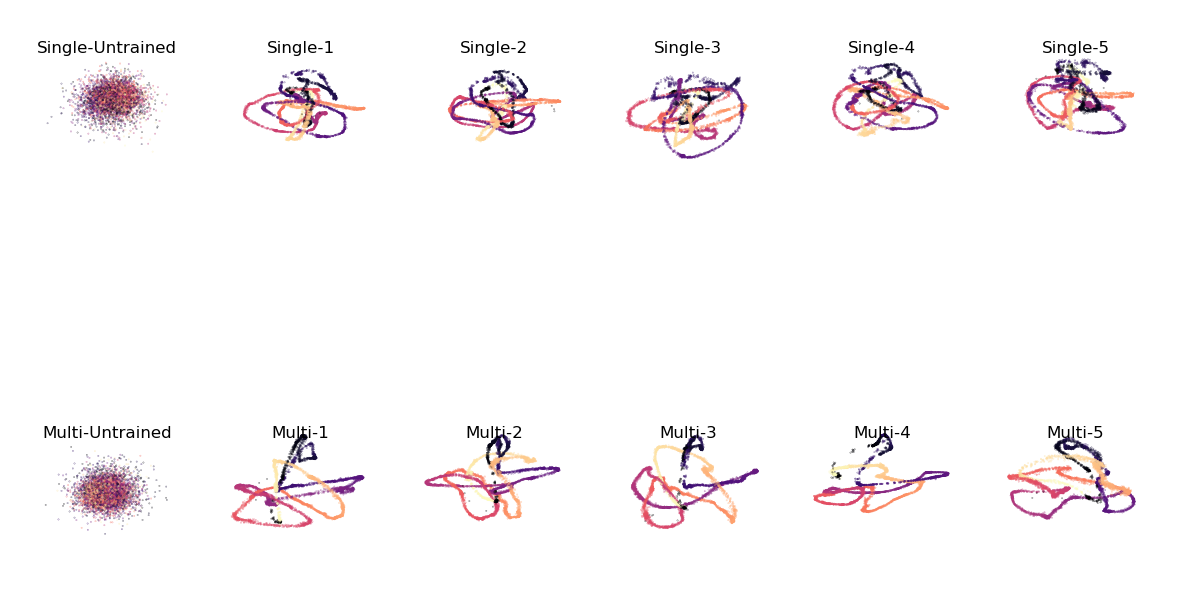

In [18]:
%matplotlib inline

num_layers = len(embeddings_single)

fig = plt.figure(figsize=(10,6))
fig, axs = plt.subplots(2, num_layers+1, figsize=(15, 10), subplot_kw={'projection': '3d'})
# Flatten the array of axes for easier indexing
axs = axs.flatten()

# Separate the axes into untrained and trained lists
axs_single = axs[:num_layers+1]
axs_multi = axs[num_layers+1:]

i = 0
for  ax, ax_multi in zip( axs_single, axs_multi):
    if i == 0:
        embeddings_single_plot = embeddings_untrained_single
        embeddings_multi_plot = embeddings_untrained_multi
        title = 'Untrained'
    else:
        embeddings_single_plot = embeddings_single[i-1]
        embeddings_multi_plot = embeddings_multi[i-1]
        title = i
    ax = plot_allen(ax, embeddings_single_plot, y)
    ax.set_title(f'Single-{title}', y=1, pad=-20)
    ax.axis('off')
    ax_multi = plot_allen(ax_multi, embeddings_multi_plot, y)
    ax_multi.set_title(f'Multi-{title}', y=1, pad=-20)
    ax_multi.axis('off')
    i += 1


plt.subplots_adjust(wspace=0,
                    hspace=0)
plt.show()

# MODEL EVALUATION

Here we get decoding of all the models to get understanding of our models and performance.

In [23]:
results_untrained = np.zeros((len(models_untrained),3))
results_single = np.zeros((len(models_single),3))
results_multi = np.zeros((len(models_multi),3))

# labels
label_train = y
label_test = discrete_labels_val[3]

#data
data_train = X
data_test = valid_datas[3].neural

# UNTRAINED
for i,model in enumerate(models_untrained):
  if i == 1: # multi session, need to add the session id
    train = model.transform(data_train, session_id = 3)
    test = model.transform(data_test, session_id = 3)
  else:
    train = model.transform(data_train)
    test = model.transform(data_test)

  results_untrained[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)



# SINGLE
for i,model in enumerate(models_single):
  train = model.transform(X)
  test = model.transform(data_test)
  results_single[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)

# MULTI
for i,model in enumerate(models_multi):
  train = model.transform(data_train, session_id=3)
  test = model.transform(data_test, session_id=3)
  results_multi[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)


In [24]:
mean_results_untrained = np.mean(results_untrained, axis = 0)
mean_results_single = np.mean(results_single, axis = 0)
mean_results_multi = np.mean(results_multi, axis = 0)

print('UNTRAINED: ', 'Mean test score (R2): ', round(mean_results_untrained[0],4),'Mean test acc: ', round(mean_results_untrained[2],2),'%')
print('Mean test acc Single: ',  round(mean_results_single[2],2),'%')
print('Mean test acc Multi: ', round(mean_results_multi[2],2),'%')

UNTRAINED:  Mean test score (R2):  -0.5178 Mean test acc:  19.17 %
Mean test acc Single:  78.07 %
Mean test acc Multi:  66.16 %


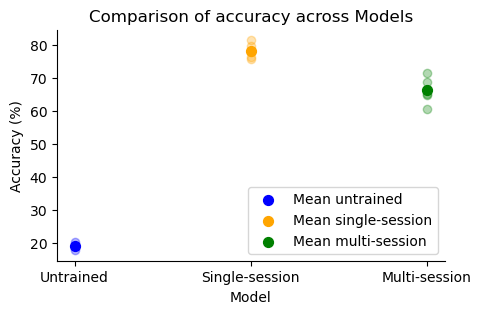

In [25]:
# PLOTTING
# Extract the position error from each model
acc1 = results_untrained[:,2]
acc2 = results_single[:, 2]
acc3 = results_multi[:, 2]

# Compute the mean of the position error for each model
mean_error1 = np.mean(acc1)
mean_error2 = np.mean(acc2)
mean_error3 = np.mean(acc3)
fig, ax = plt.subplots(figsize=(5, 3))

# X positions for each model
x_positions = [1, 2, 3]

# Plot the position errors
ax.scatter(np.ones_like(acc1) * x_positions[0], acc1,color='blue', alpha = 0.3)
ax.scatter(np.ones_like(acc2) * x_positions[1], acc2, color='orange', alpha = 0.3)
ax.scatter(np.ones_like(acc3) * x_positions[2], acc3, color='green', alpha = 0.3)
#edgecolors='black',
# Plot the means
ax.scatter(x_positions[0], mean_error1, color='blue',  s=50, label='Mean untrained', zorder=5)
ax.scatter(x_positions[1], mean_error2, color='orange', s=50, label='Mean single-session', zorder=5)
ax.scatter(x_positions[2], mean_error3, color='green',  s=50, label='Mean multi-session', zorder=5)

# Set labels and title
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of accuracy across Models')
ax.set_xticks(x_positions)
ax.set_xticklabels(['Untrained', 'Single-session', 'Multi-session'])
ax.legend()
sns.despine()
# Show the plot
plt.show()

We have good decoding accuracy for the models, we can proceed to the analysis

# Neural Network Analysis

1. Put hooks on the model
2. Feed data and get activations (Y Matrix)
3. Create setup for GLM
  - X matrix (regressors normalized)
  - Y matrix (neural activation normalized by layer)


## Get activations for all models

**REMINDER** models variables are defined as follows:
- models_untrained  
- models_single  
- models_multi


### Define hooks and activation functions

In [26]:
# Dictionary to store activations of all models
activations = {}

# Function to create a hook that stores the activations in the dictionary
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().squeeze().numpy()
    return hook


def attach_hooks_conv(model,name,bool_train = False): # only attaches hooks on convolutional layers
  if not(bool_train): # attach _UT when it's not a trained model
    string_ut = 'UT'
  else:
    string_ut = ''
  num_conv = 1
  for i in range (len(model.net)):
    if isinstance(model.net[i], nn.Conv1d):
      model.net[i].register_forward_hook(get_activation(f'{name}{string_ut}_layer{num_conv}'))
      num_conv += 1

    elif bool(model.net[i]._modules): # empty dict evaluate to false. here we go in the _Skip connection where some conv may be stored
      for j in range (len(model.net[i].module)):
        if isinstance(model.net[i].module[j], nn.Conv1d):
          model.net[i].module[j].register_forward_hook(get_activation(f'{name}{string_ut}_layer{i}'))
          num_conv += 1


### Attach hooks and forward pass

In [27]:
data = data_test
label = label_test
label_extended = np.pad(label, ((5, 5)), mode="edge") #padding the labels to match the embedding sizes


# UNTRAINED
untrained_embeddings = []
attach_hooks_conv(models_untrained[1].model_[3],'multi',False)
attach_hooks_conv(models_untrained[0].model_,'single',False)

# do a forward pass
untrained_embeddings.append(models_untrained[1].transform(data,session_id = 3).T)
untrained_embeddings.append(models_untrained[0].transform(data).T)

# SINGLE
single_embeddings = []
for i,model in enumerate(models_single):
  attach_hooks_conv(model.model_,f'single{i}',True)
  single_embeddings.append(model.transform(data).T)

# MULTI
multi_embeddings = []
for i,model in enumerate(models_multi):
  attach_hooks_conv(model.model_[3],f'multi{i}',True)
  multi_embeddings.append(model.transform(data,session_id = 3).T)


print(activations.keys())


dict_keys(['multiUT_layer1', 'multiUT_layer2', 'multiUT_layer3', 'multiUT_layer4', 'multiUT_layer5', 'singleUT_layer1', 'singleUT_layer2', 'singleUT_layer3', 'singleUT_layer4', 'singleUT_layer5', 'single0_layer1', 'single0_layer2', 'single0_layer3', 'single0_layer4', 'single0_layer5', 'single1_layer1', 'single1_layer2', 'single1_layer3', 'single1_layer4', 'single1_layer5', 'single2_layer1', 'single2_layer2', 'single2_layer3', 'single2_layer4', 'single2_layer5', 'single3_layer1', 'single3_layer2', 'single3_layer3', 'single3_layer4', 'single3_layer5', 'single4_layer1', 'single4_layer2', 'single4_layer3', 'single4_layer4', 'single4_layer5', 'multi0_layer1', 'multi0_layer2', 'multi0_layer3', 'multi0_layer4', 'multi0_layer5', 'multi1_layer1', 'multi1_layer2', 'multi1_layer3', 'multi1_layer4', 'multi1_layer5', 'multi2_layer1', 'multi2_layer2', 'multi2_layer3', 'multi2_layer4', 'multi2_layer5', 'multi3_layer1', 'multi3_layer2', 'multi3_layer3', 'multi3_layer4', 'multi3_layer5', 'multi4_layer1

Separate activations into 3 lists

In [28]:
activations_UT = []
activations_single = []
activations_multi = []

# Populate matrices
for key, value in activations.items():
    parts = key.split('_')
    prefix = parts[0]

    if prefix == 'multiUT' or prefix == 'singleUT':
        activations_UT.append(value.squeeze())

    elif prefix.startswith('single'):
        activations_single.append(value.squeeze())

    elif prefix.startswith('multi'):
        activations_multi.append(value.squeeze())

In [29]:
print(len(activations_UT))

10


### Plotting

For the plotting we will plot:
- single Untrained vs one instance of a trained single
- multi Untrained vs one instance of a trained multi

In [30]:
# MULTI
embeddings_untrained_multi = activations_UT[:5] + [untrained_embeddings[0]]
embeddings_trained_multi = activations_multi[:5] + [multi_embeddings[0]] # first multi model from 0-5 and add embedding

# SINGLE
embeddings_untrained_single = activations_UT[5:] + [untrained_embeddings[1]]
embeddings_trained_single = activations_single[:5] + [single_embeddings[0]]

sample_plot = 200

#### Activations Single

In [ ]:
solver = 'single-session'
plot_activations(data, embeddings_untrained_single,embeddings_trained_single,sample_plot,solver)

In [ ]:
solver = 'multi-session'
plot_activations(data,embeddings_untrained_multi,embeddings_trained_multi,sample_plot,solver)

In [ ]:
solver = 'single vs multi'
plot_activations(data,embeddings_trained_single,embeddings_trained_multi,sample_plot,solver,comparison = 'trained')

#### CEBRA embeddings

In [ ]:
# prepare the labels
labels_list = [label_extended[1:-1], label_extended[2:-2],label_extended[3:-3],label_extended[4:-4],
            label_extended[5:-5], label_extended[5:-5]]

plot_cebra_embeddings_layers(embeddings_untrained_single, embeddings_trained_single, labels_list,solver = 'single-session', comparison='untrained',dataset='Allen')
plot_cebra_embeddings_layers(embeddings_untrained_multi, embeddings_trained_multi, labels_list,solver = 'multi-session',comparison='untrained',dataset='Allen')
plot_cebra_embeddings_layers(embeddings_trained_single, embeddings_trained_multi, labels_list,solver = 'single vs multi',comparison='trained',dataset='Allen')

#### t-SNE across layers

In [278]:
pwd

'/Users/riccardocarpineto/Documents/CEBRA/t/Sans titre'

In [279]:
# Run this cell if you don't have the t-SNE embeddings
run = False

if run:
  points_viz = 2000 # TO DO: RERUN AVEC 2000
  embeddings_tsne_untrained_single = []
  embeddings_tsne_trained_single = []
  embeddings_tsne_untrained_multi = []
  embeddings_tsne_trained_multi = []

  for i in tqdm(range(len(embeddings_trained_single))):
    tsne = TSNE(n_components = 3)
    embeddings_tsne_untrained_single.append(tsne.fit_transform(embeddings_untrained_single[i][:,:points_viz].T))
    embeddings_tsne_trained_single.append(tsne.fit_transform(embeddings_trained_single[i][:,:points_viz].T))
    embeddings_tsne_untrained_multi.append(tsne.fit_transform(embeddings_untrained_multi[i][:,:points_viz].T))
    embeddings_tsne_trained_multi.append(tsne.fit_transform(embeddings_trained_multi[i][:,:points_viz].T))

  with open('../../tSNE/VISION/tsne_embeddings_singlesession_untrained.pkl', 'wb') as f:
    pickle.dump(embeddings_tsne_untrained_single, f)

  with open('../../tSNE/VISION/tsne_embeddings_singlesession_trained.pkl', 'wb') as f:
    pickle.dump(embeddings_tsne_trained_single, f)

  with open('../../tSNE/VISION/tsne_embeddings_multisession_untrained.pkl', 'wb') as f:
    pickle.dump(embeddings_tsne_untrained_multi, f)

  with open('../../tSNE/VISION/tsne_embeddings_multisession_trained.pkl', 'wb') as f:
    pickle.dump(embeddings_tsne_trained_multi, f)

  print('DONE')

In [280]:
# Load tsne precomputed points
with open('../../tSNE/VISION/tsne_embeddings_singlesession_untrained.pkl', 'rb') as f:
  embeddings_tsne_untrained_single = pickle.load(f)
with open('../../tSNE/VISION/tsne_embeddings_singlesession_trained.pkl', 'rb') as f:
  embeddings_tsne_trained_single = pickle.load(f)

with open('../../tSNE/VISION/tsne_embeddings_multisession_untrained.pkl', 'rb') as f:
  embeddings_tsne_untrained_multi = pickle.load(f)
#embeddings_tsne_untrained_multi = embeddings_tsne_untrained_single # TO DO: RECOMPUTE EUX AUSSI
with open('../../tSNE/VISION/tsne_embeddings_multisession_trained.pkl', 'rb') as f:
  embeddings_tsne_trained_multi = pickle.load(f)


In [ ]:
%matplotlib inline
points_viz = 2000
plot_tsne_embeddings_layers(embeddings_tsne_untrained_single,embeddings_tsne_trained_single,label_extended,sample_plot= points_viz,solver = 'single-session', comparison='untrained',data = 'Allen')
plot_tsne_embeddings_layers(embeddings_tsne_untrained_multi,embeddings_tsne_trained_multi,label_extended,sample_plot= points_viz, solver = 'multi-session', comparison='untrained',data = 'Allen')
plot_tsne_embeddings_layers(embeddings_tsne_trained_single,embeddings_tsne_trained_multi,label_extended,sample_plot= points_viz, solver = 'single vs multi',comparison='trained',data = 'Allen')



#### CKA

###### Computation of the CKA matrix

**REMINDER** we need to use the activations and not embeddings, they were just for plotting and on 1 model instantiation only.

In [35]:
run = True
if run:
  embeddings_untrained_multi = activations_UT[:5] + [untrained_embeddings[0]]
  embeddings_untrained_single = activations_UT[5:] + [untrained_embeddings[1]]
  # define cka matrices
  cka_matrix_single = np.zeros((5,len(embeddings_untrained_single))) # number of Models (5) X number of layers
  cka_matrix_multi = np.zeros((5,len(embeddings_untrained_single))) # number of Models (5) X number of layers
  cka_matrix_sm = np.zeros((5,len(embeddings_untrained_single)))

  for i in tqdm(range(5)): # per model
    # MULTI
    embeddings_trained_multi = activations_multi[i*5:(i+1)*5] + [multi_embeddings[i]] # first multi model from 0-5 and add embedding

    # SINGLE
    embeddings_trained_single = activations_single[i*5:(i+1)*5] + [single_embeddings[i]]

    for j in range(len(embeddings_trained_single)):

      cka_matrix_single[i,j] = cka(gram_linear(embeddings_untrained_single[j].T), gram_linear(embeddings_trained_single[j].T))
      cka_matrix_multi[i,j] = cka(gram_linear(embeddings_untrained_multi[j].T), gram_linear(embeddings_trained_multi[j].T))
      cka_matrix_sm[i,j] = cka(gram_linear(embeddings_trained_single[j].T), gram_linear(embeddings_trained_multi[j].T))



100%|██████████| 5/5 [00:01<00:00,  2.68it/s]


In [36]:
if run:
  # define cka matrices
  cka_matrix_singlevsingle = np.zeros((5,len(embeddings_untrained_single))) # number of Models (5) X number of layers
  cka_matrix_multivmulti = np.zeros((5,len(embeddings_untrained_single))) # number of Models (5) X number of layers

  embeddings_trained_single = []
  embeddings_trained_multi = []
  for i in range(5): # per model
    
    embeddings_trained_single.append(activations_single[i*5:(i+1)*5] + [single_embeddings[i]])
    embeddings_trained_multi.append(activations_multi[i*5:(i+1)*5] + [multi_embeddings[i]])

  for i in tqdm(range (len(embeddings_trained_single))):
      for j in range(len(embeddings_untrained_single)):

          cka_matrix_singlevsingle[i,j] = cka(gram_linear(embeddings_trained_single[0][j].T), gram_linear(embeddings_trained_single[i][j].T))
          cka_matrix_multivmulti[i,j] = cka(gram_linear(embeddings_trained_multi[0][j].T), gram_linear(embeddings_trained_multi[i][j].T))

100%|██████████| 5/5 [00:01<00:00,  3.98it/s]


In [37]:
load = True
save = False
if save:
  # SAVE MATRICES
  np.save('FinalModels/VISION/cka_matrix_single_test.npy', cka_matrix_single)
  np.save('FinalModels/VISION/cka_matrix_multi_test.npy', cka_matrix_multi)
  np.save('FinalModels/VISION/cka_matrix_sm_test.npy', cka_matrix_sm)
  np.save('FinalModels/VISION/cka_matrix_singlevsingle_test.npy', cka_matrix_singlevsingle)
  np.save('FinalModels/VISION/cka_matrix_cka_matrix_multivmulti_test.npy',cka_matrix_multivmulti)
elif load:
  # LOAD MATRICES
  cka_matrix_single = np.load('FinalModels/VISION/cka_matrix_single_test.npy')
  cka_matrix_multi = np.load('FinalModels/VISION/cka_matrix_multi_test.npy')
  cka_matrix_sm = np.load('FinalModels/VISION/cka_matrix_sm_test.npy')
  cka_matrix_singlevsingle = np.load('FinalModels/VISION/cka_matrix_singlevsingle_test.npy')
  cka_matrix_multivmulti = np.load('FinalModels/VISION/cka_matrix_cka_matrix_multivmulti_test.npy')



FileNotFoundError: [Errno 2] No such file or directory: 'FinalModels/VISION/cka_matrix_single_test.npy'

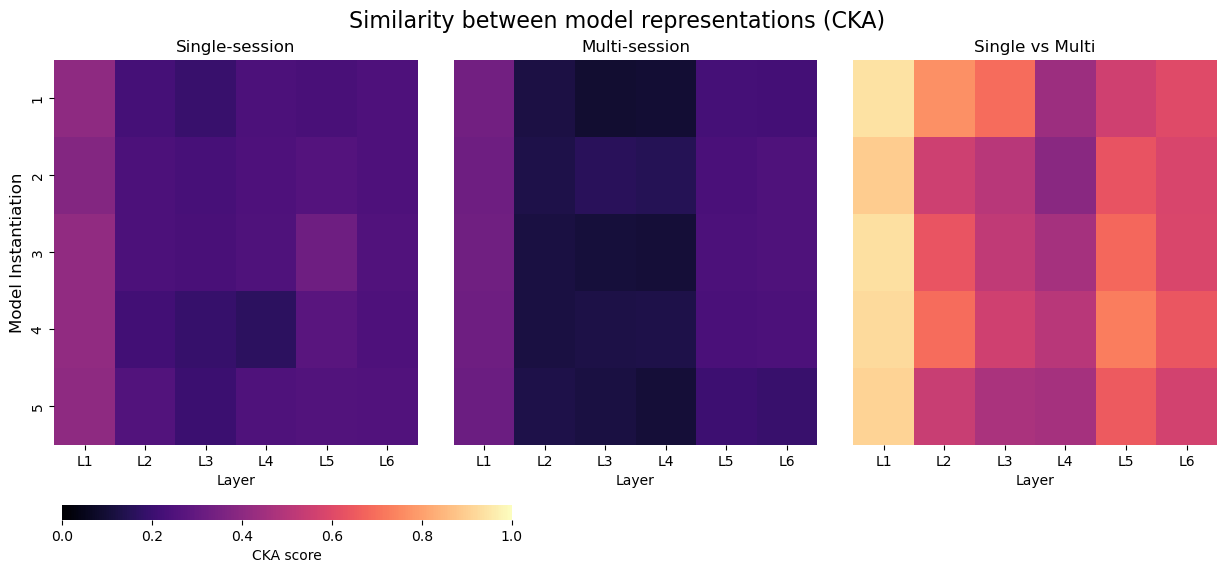

In [38]:
# Create a figure and set of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Define the heat map parameters
#cbar_ax = fig.add_axes([.91, .3, .03, .4])
cbar_ax = fig.add_axes([0.13, -0.04, 0.3, 0.03])  # Position for the color bar

heatmap_kwargs = {'cbar': True, 'cbar_ax': cbar_ax, 'vmin': 0, 'vmax': 1, 'cmap': 'magma','cbar_kws': {'label': 'CKA score','orientation' : 'horizontal'}}

num_layers = cka_matrix_single.shape[1]
# Plot each heat map
sns.heatmap(cka_matrix_single, ax=axs[0], **heatmap_kwargs)
sns.heatmap(cka_matrix_multi, ax=axs[1], **heatmap_kwargs)
sns.heatmap(cka_matrix_sm, ax=axs[2], **heatmap_kwargs)

# Set titles and labels
axs[0].set_title('Single-session')
axs[1].set_title('Multi-session')
axs[2].set_title('Single vs Multi')

for ax in axs:
    ax.set_xlabel('Layer')
    if ax == axs[0]:
        ax.set_ylabel('Model Instantiation', fontsize = 12)
        ax.set_yticks(np.arange(5) + 0.5)
        ax.set_yticklabels([m for m in range(1, 6)])
    else:
        ax.set_ylabel('')
        ax.set_yticks([])

    ax.set_xticks(np.arange(num_layers) + 0.5)
    ax.set_xticklabels([f'L{l}' for l in range(1,num_layers+1)])

# Adjust layout
plt.subplots_adjust(wspace=0.1, right=0.9)
fig.suptitle('Similarity between model representations (CKA)', fontsize=16)
plt.show()


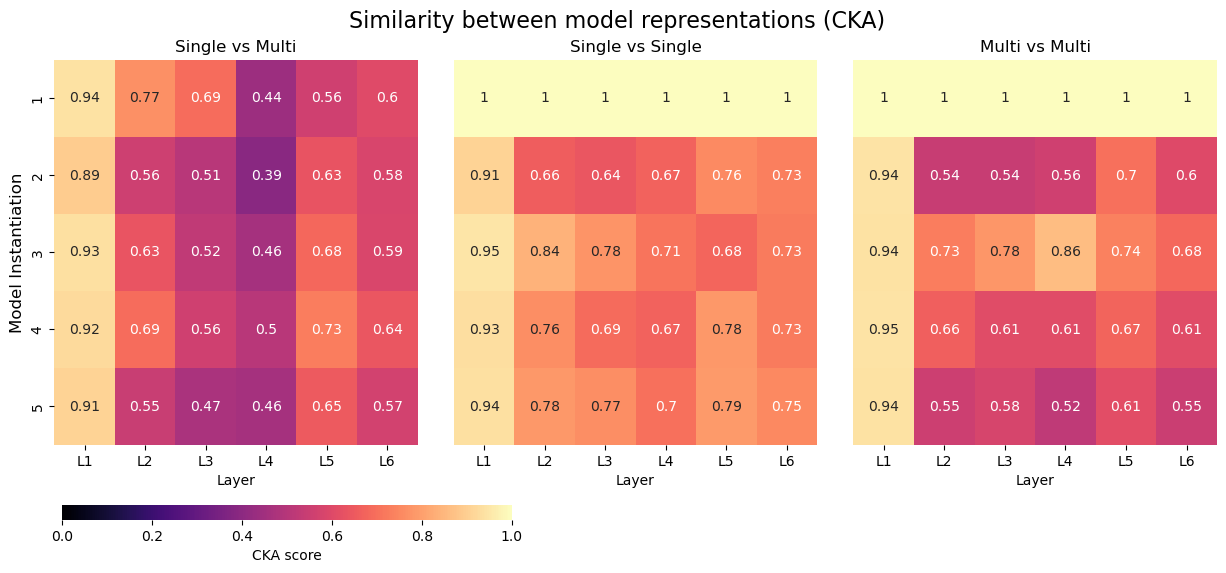

In [39]:
# Create a figure and set of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Define the heat map parameters
#cbar_ax = fig.add_axes([.91, .3, .03, .4])
cbar_ax = fig.add_axes([0.13, -0.04, 0.3, 0.03])  # Position for the color bar

heatmap_kwargs = {'cbar': True, 'cbar_ax': cbar_ax, 'vmin': 0, 'vmax': 1, 'cmap': 'magma','cbar_kws': {'label': 'CKA score','orientation' : 'horizontal'}}

num_layers = cka_matrix_single.shape[1]
# Plot each heat map
sns.heatmap(cka_matrix_sm, ax=axs[0],annot = True, **heatmap_kwargs)
sns.heatmap(cka_matrix_singlevsingle, ax=axs[1],annot = True, **heatmap_kwargs)
sns.heatmap(cka_matrix_multivmulti, ax=axs[2],annot = True, **heatmap_kwargs)

# Set titles and labels
axs[0].set_title('Single vs Multi')
axs[1].set_title('Single vs Single')
axs[2].set_title('Multi vs Multi')

for ax in axs:
    ax.set_xlabel('Layer')
    if ax == axs[0]:
        ax.set_ylabel('Model Instantiation', fontsize = 12)
        ax.set_yticks(np.arange(5) + 0.5)
        ax.set_yticklabels([m for m in range(1, 6)])
    else:
        ax.set_ylabel('')
        ax.set_yticks([])

    ax.set_xticks(np.arange(num_layers) + 0.5)
    ax.set_xticklabels([f'L{l}' for l in range(1,num_layers+1)])

# Adjust layout
plt.subplots_adjust(wspace=0.1, right=0.9)
fig.suptitle('Similarity between model representations (CKA)', fontsize=16)
plt.show()


#### RDM

##### Setup

We need to change the frames into bins of similar frames. The easiest option is to take bins of close by frames. The video was shown at 30Hz so we can split into bins of 1s, i.e. 30 frames.

The frames go from 0 to 900. We can separate into 30 bins: bins of 30 frames.

In [ ]:
plt.plot(label[:])

In [43]:
# step 1 is to find the idxs for each bin
from random import sample
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore

num_samples = 30
num_bins = 30
step_distance = 30
idxs = np.zeros((num_bins,num_samples))

j = 0
for i in range(num_bins):

  full_idxs = np.where((label[:] >= j*step_distance) & (label[:] < (j+1)*step_distance))[0]
  idxs[i,:] = sample(list(full_idxs), num_samples)
  j = j + 1

idxs = idxs.astype(int)

In [44]:
# step 2 is to get neural data and last embedding data of these indices in an array.

# Neural
neural_data = data[list(idxs.flatten()),:]

# Output Embedding of first multi-session model instance
embeddings_trained_multi_all = activations_multi[:5] + [multi_embeddings[0]]
embeddings_trained_multi = multi_embeddings[0][:,idxs.flatten()].T # .T to keep consistency between neural data and this

##### Computation

In [45]:
neural_data_rdm = squareform(pdist(neural_data,metric='euclidean'))

#intermediate layers
embeddings_all_rdm = []
embeddings_all_rdm_corr = []
for i in range(len(embeddings_trained_multi_all)):
  embeddings_all_rdm.append(squareform(pdist(embeddings_trained_multi_all[i][:,idxs.flatten()].T,metric='euclidean')))
  embeddings_all_rdm_corr.append(pdist(embeddings_trained_multi_all[i][:,idxs.flatten()].T,metric='correlation'))

embedding_rdm = squareform(pdist(embeddings_trained_multi,metric='euclidean'))

##### Plotting

In [46]:
def plot_rdm(rdms, titles, metric='Normalized Euclidean distance'):
    # Create the plot
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(10, 7)

    # Generate tick labels
    tick_labels = [str(i) for i in range(0, 930, 30)]

    for i, rdm in enumerate(rdms):
        # Display the RDM using imshow
        cax = ax[i].imshow(rdm, cmap='viridis', aspect='auto')

        # Set title and show the plot
        ax[i].set_title(titles[i])

        # Set ticks and tick labels
        num_ticks = len(tick_labels)
        ax[i].set_xticks(np.linspace(0, rdm.shape[1] - 1, num_ticks))
        ax[i].set_yticks(np.linspace(0, rdm.shape[0] - 1, num_ticks))
        ax[i].set_xticklabels(tick_labels, rotation=90, ha='right')
        ax[i].set_yticklabels(tick_labels)

    plt.suptitle('Representational Dissimilarity Matrix (RDM)')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)

    # Add colorbar with a label
    fig.colorbar(cax, ax=ax, orientation='horizontal', fraction=0.05, label=metric)

    plt.show()

# Min-Max normalization function
def normalize_minmax(rdm):
    rdm_min = np.min(rdm)
    rdm_max = np.max(rdm)
    return (rdm - rdm_min) / (rdm_max - rdm_min)


In [ ]:
# just to show that with correlation it doesn't work with neural input
neural_data_rdm_corr = squareform(pdist(neural_data,metric='correlation'))
embedding_rdm_corr = squareform(pdist(embeddings_trained_multi,metric='correlation'))

plot_rdm([neural_data_rdm_corr,embedding_rdm_corr],['Neural input', 'Output Layer'],metric = 'Dissimilarity')

In [ ]:
# Normalize the RDMs using Min-Max normalization
rdm1_normalized = normalize_minmax(neural_data_rdm)
rdm2_normalized = normalize_minmax(embedding_rdm)

plot_rdm([rdm1_normalized,rdm2_normalized],['Neural input', 'Output Layer'],metric = 'Normalized Euclidean distance')

##### Comparison to Oracle

In [51]:
# Create Oracle RDM.
one_class = np.ones((30, 30))
all_classes = [one_class for _ in range(30)]
block_rdm_sqform = 1 - block_diag(*all_classes)
oracle_rdm = squareform(block_rdm_sqform)

In [ ]:
# Normalize the RDMs using Min-Max normalization
for i in range (len(embeddings_all_rdm_corr)):
  print('CORRELATION: ', 1-correlation(oracle_rdm,embeddings_all_rdm_corr[i]))

  embedding_rdm = squareform(embeddings_all_rdm_corr[i])
  rdm2_normalized = normalize_minmax(embedding_rdm)
  if i == len(embeddings_all_rdm_corr)-1:
    layer_title = 'Output Layer'
  else:
    layer_title = f'Layer{i+1}'

  plot_rdm([block_rdm_sqform,rdm2_normalized],['Oracle RDM', layer_title],metric = 'Dissimilarity')

In [ ]:
# SAME THING BUT FOR SINGLE SESSION

embeddings_trained_single_all = activations_single[:5] + [single_embeddings[0]]

#intermediate layers
embeddings_all_rdm_single_corr = []

for i in range(len(embeddings_trained_single_all)):
  embeddings_all_rdm_single_corr.append(pdist(embeddings_trained_single_all[i][:,idxs.flatten()].T,metric='correlation'))

# Normalize the RDMs using Min-Max normalization
for i in range (len(embeddings_all_rdm_single_corr)):
  print('CORRELATION: ', 1-correlation(oracle_rdm,embeddings_all_rdm_single_corr[i]))

  embedding_rdm = squareform(embeddings_all_rdm_single_corr[i])
  rdm2_normalized = normalize_minmax(embedding_rdm)
  if i == len(embeddings_all_rdm_single_corr)-1:
    layer_title = 'Output Layer'
  else:
    layer_title = f'Layer{i+1}'

  plot_rdm([block_rdm_sqform,rdm2_normalized],['Oracle RDM', layer_title],metric = 'Dissimilarity')

In [ ]:
# BETWEEN MULTI AND SINGLE

# Normalize the RDMs using Min-Max normalization
for i in range (len(embeddings_all_rdm_corr)):
  print('CORRELATION: ', 1-correlation(embeddings_all_rdm_single_corr[i],embeddings_all_rdm_corr[i]))

  embedding_rdm1 = squareform(embeddings_all_rdm_single_corr[i])
  rdm1_normalized = normalize_minmax(embedding_rdm1)

  embedding_rdm2 = squareform(embeddings_all_rdm_corr[i])
  rdm2_normalized = normalize_minmax(embedding_rdm2)
  if i == len(embeddings_all_rdm_corr)-1:
    layer_title = 'Output Layer'
  else:
    layer_title = f'Layer{i+1}'

  plot_rdm([rdm1_normalized,rdm2_normalized],[layer_title+'Single', layer_title+'Multi'],metric = 'Dissimilarity')

In [55]:
# For each model, compute distance to Oracle RDM, initially just using Correlation Distance
# Save for each layer : model_name, layer_name, layer_number, layer_reldepth, distance_to_oracle, arch_type

all_corrs_multi = []
all_corrs_single = []

for j in range(5):
  embeddings_trained_multi_all = activations_multi[j*5:(j+1)*5] + [multi_embeddings[j]]
  embeddings_trained_single_all = activations_single[j*5:(j+1)*5] + [single_embeddings[j]]

  correlation_RDM_multi = []
  correlation_RDM_single = []

  for i in range(len(embeddings_trained_multi_all)):
    rmd_corr_multi = pdist(embeddings_trained_multi_all[i][:,idxs.flatten()].T,metric='correlation')
    correlation_RDM_multi.append(1-correlation(oracle_rdm,rmd_corr_multi))

    rmd_corr_single = pdist(embeddings_trained_single_all[i][:,idxs.flatten()].T,metric='correlation')
    correlation_RDM_single.append(1-correlation(oracle_rdm,rmd_corr_single))

  all_corrs_multi.append(correlation_RDM_multi)
  all_corrs_single.append(correlation_RDM_single)


all_corrs_UT = []

embeddings_untrained_multi_all = activations_UT[:5] + [untrained_embeddings[0]]
embeddings_untrained_single_all = activations_UT[5:] + [untrained_embeddings[1]]

correlation_RDM_multi = []
correlation_RDM_single = []

for i in range(len(embeddings_untrained_multi_all)):

    rmd_corr_multi_UT = pdist(embeddings_untrained_multi_all[i][:,idxs.flatten()].T,metric='correlation')
    correlation_RDM_multi.append(1-correlation(oracle_rdm,rmd_corr_multi_UT))

    rmd_corr_single_UT = pdist(embeddings_untrained_single_all[i][:,idxs.flatten()].T,metric='correlation')
    correlation_RDM_single.append(1-correlation(oracle_rdm,rmd_corr_single_UT))

all_corrs_UT.append(correlation_RDM_multi)
all_corrs_UT.append(correlation_RDM_single)


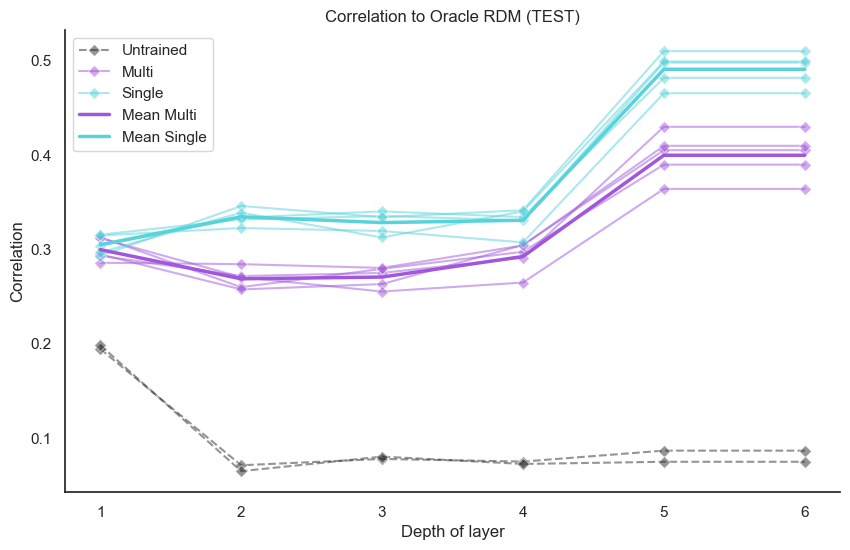

In [57]:
# Calculate means
mean_multi = np.mean(all_corrs_multi, axis=0)
mean_single = np.mean(all_corrs_single, axis=0)

# Create the plot
plt.figure(figsize=(10, 6))

sns.set(style="white")
# Define pastel colors
colors = sns.color_palette("hls",8)
pastel_purple = colors[6]
pastel_blue = colors[4]
grey = sns.color_palette("Greys")[5]

# Plot untrained data
for i in range(2):
    sns.lineplot(x=np.arange(1,len(all_corrs_single[i])+1), y=all_corrs_UT[i],
                 linestyle='--', marker='D', color=grey, alpha = 0.5,label='Untrained' if i == 0 else "")

# Plot multi data
for i in range(5):
    sns.lineplot(x=np.arange(1,len(all_corrs_single[i])+1), y=all_corrs_multi[i],
                 linestyle='-', marker='D', color=pastel_purple,alpha = 0.5, label='Multi' if i == 0 else "")

# Plot single data
for i in range(5):
    sns.lineplot(x=np.arange(1,len(all_corrs_single[i])+1), y=all_corrs_single[i],
                 linestyle='-', marker='D', color=pastel_blue,alpha = 0.5, label='Single' if i == 0 else "")

# Plot mean lines for multi and single
sns.lineplot(x=np.arange(1,len(all_corrs_single[i])+1), y=mean_multi,
             linestyle='-', color=pastel_purple, linewidth=2.5, label='Mean Multi')
sns.lineplot(x=np.arange(1,len(all_corrs_single[i])+1), y=mean_single,
             linestyle='-', color=pastel_blue, linewidth=2.5, label='Mean Single')

# Customize plot
plt.xlabel('Depth of layer')
plt.ylabel('Correlation')
plt.title('Correlation to Oracle RDM (TEST)')
sns.despine()
plt.legend()
plt.show()


### Distance across Layers

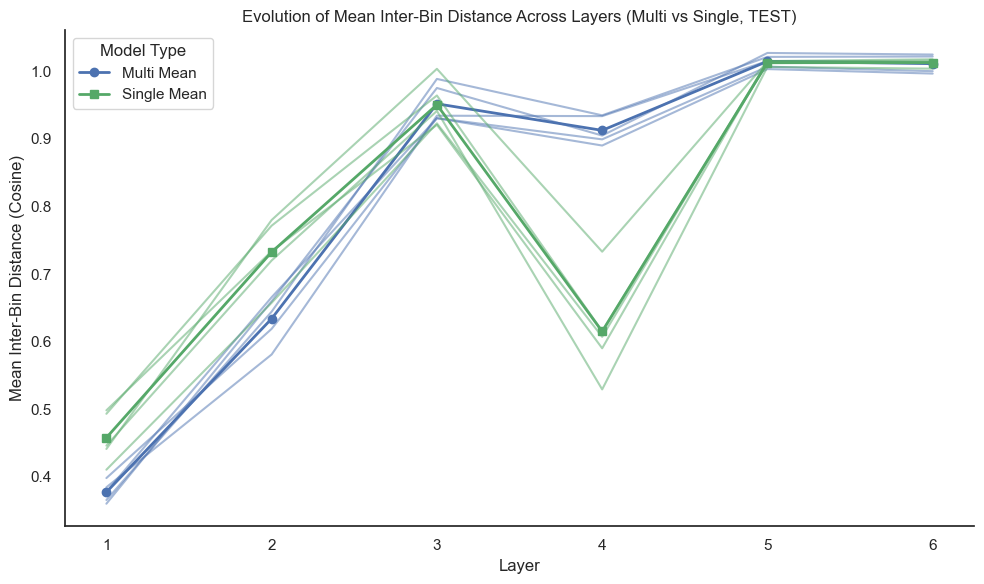

In [59]:
# Assuming idxs is already defined as in your original code
# Define the number of bins and samples
num_bins = 30
num_samples = 30

# Function to compute centroids and inter-bin distances for a given embeddings list
def compute_inter_bin_distances(embeddings_list):
    centroids_all = []
    for i in range(len(embeddings_list)):
        layer_centroids = []
        for bin_idx in range(num_bins):
            bin_indices = idxs[bin_idx, :]  # Indices for the current bin
            bin_data = embeddings_list[i][:, bin_indices.flatten()].T  # Get data for the current bin
            centroid = np.mean(bin_data, axis=0)  # Compute centroid
            layer_centroids.append(centroid)
        centroids_all.append(np.array(layer_centroids))

    # Step 2: Compute Inter-Bin Distances using Cosine Distance
    inter_bin_distances_all = []
    for layer_centroids in centroids_all:
        # Compute pairwise distances between centroids using cosine distance
        distances = cdist(layer_centroids, layer_centroids, metric='cosine')
        inter_bin_distances_all.append(distances)

    # Compute the mean inter-bin distance for each layer, excluding self-distances
    mean_inter_bin_distances_all = []
    for distances in inter_bin_distances_all:
        # Extract non-diagonal elements
        non_diagonal_distances = distances[~np.eye(distances.shape[0], dtype=bool)]
        mean_distance = np.mean(non_diagonal_distances)
        mean_inter_bin_distances_all.append(mean_distance)

    return mean_inter_bin_distances_all

# Create lists to store the inter-bin distances for each model instance
multi_list = []
single_list = []

# Loop over the 5 instances of each model and compute inter-bin distances
for j in range(5):
    embeddings_trained_multi_all = activations_multi[j*5:(j+1)*5] + [multi_embeddings[j]]
    embeddings_trained_single_all = activations_single[j*5:(j+1)*5] + [single_embeddings[j]]

    # Compute inter-bin distances for multi and single model instances
    mean_inter_bin_distances_multi = compute_inter_bin_distances(embeddings_trained_multi_all)
    mean_inter_bin_distances_single = compute_inter_bin_distances(embeddings_trained_single_all)

    multi_list.append(mean_inter_bin_distances_multi)
    single_list.append(mean_inter_bin_distances_single)

# Step 3: Plotting

# Get the number of layers from the length of any model's inter-bin distances (assuming all layers are the same)
layers = list(range(1, len(multi_list[0]) + 1))  # Layer range (1 to number of layers)

# Set up the plot
plt.figure(figsize=(10, 6))

# Plot for Multi model instances
for i in range(5):
    plt.plot(layers, multi_list[i], alpha=0.5, color='b')  # Plot with transparency for individual instances

# Plot the mean of Multi model instances
mean_multi = np.mean(multi_list, axis=0)
plt.plot(layers, mean_multi, marker='o', color='b', label='Multi Mean', linewidth=2)

# Plot for Single model instances
for i in range(5):
    plt.plot(layers, single_list[i], alpha=0.5, color='g')  # Plot with transparency for individual instances

# Plot the mean of Single model instances
mean_single = np.mean(single_list, axis=0)
plt.plot(layers, mean_single, marker='s', color='g', label='Single Mean', linewidth=2)

# Customize the plot
plt.xlabel('Layer')
plt.ylabel('Mean Inter-Bin Distance (Cosine)')
plt.title('Evolution of Mean Inter-Bin Distance Across Layers (Multi vs Single, TEST)')
plt.legend(title='Model Type')
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
def compute_intra_bin_distances(embeddings_list):
    intra_bin_distances_all = []
    for i in range(len(embeddings_list)):
        
        # one list per layer
        layer_intra_distances = []

        # for each bin compute the mean distance
        for bin_idx in range(num_bins):

            bin_indices = idxs[bin_idx, :]  
            bin_data = embeddings_list[i][:, bin_indices.flatten()].T 
            distances = pdist(bin_data, metric='cosine')  # Pairwise distances within the bin -> distances is list of x1x2,x1x3,x1x4...
            mean_intra_distance = np.mean(distances)  # Mean of the pairwise distances
            layer_intra_distances.append(mean_intra_distance)
        
        # a list of arrays per layers
        intra_bin_distances_all.append(np.array(layer_intra_distances))
    
    # Compute the mean intra-bin distance for each layer
    mean_intra_bin_distances_all = []
    std_intra_bin_distances_all = []

    for layer_intra_distances in intra_bin_distances_all:
        mean_intra_distance = np.mean(layer_intra_distances)
        mean_intra_bin_distances_all.append(mean_intra_distance)
        std_intra_bin_distances_all.append(np.std(layer_intra_distances))
    
    return mean_intra_bin_distances_all,std_intra_bin_distances_all

# Create lists to store the intra-bin distances for each model instance
multi_intra_list = []
single_intra_list = []

# STD
multi_intra_list_std = []
single_intra_list_std = []

# Loop over the 5 instances of each model and compute intra-bin distances
for j in range(5):
    embeddings_trained_multi_all = activations_multi[j*5:(j+1)*5] + [multi_embeddings[j]]
    embeddings_trained_single_all = activations_single[j*5:(j+1)*5] + [single_embeddings[j]]

    # Compute intra-bin distances for multi and single model instances
    mean_intra_bin_distances_multi,std_multi = compute_intra_bin_distances(embeddings_trained_multi_all)
    mean_intra_bin_distances_single,std_single = compute_intra_bin_distances(embeddings_trained_single_all)

    multi_intra_list.append(mean_intra_bin_distances_multi)
    single_intra_list.append(mean_intra_bin_distances_single)

    #multi_intra_list.append(std_multi)
    #single_intra_list.append(std_single)

    multi_intra_list_std.append(std_multi)
    single_intra_list_std.append(std_single)


# Step 3: Plotting

layers = list(range(1, len(multi_intra_list[0]) + 1))

plt.figure(figsize=(10, 6))

# Plot for Multi model instances
for i in range(len(multi_intra_list)):
    plt.plot(layers, multi_intra_list[i], alpha=0.5, color=pastel_purple)  # Plot with transparency for individual instances

# Plot the mean of Multi model instances
mean_multi_intra = np.mean(multi_intra_list, axis=0)
plt.plot(layers, mean_multi_intra, marker='o', color=pastel_purple, label='Multi Intra Mean', linewidth=2)

# Plot for Single model instances
for i in range(len(multi_intra_list)):
    plt.plot(layers, single_intra_list[i], alpha=0.5, color=pastel_blue)  # Plot with transparency for individual instances

# Plot the mean of Single model instances
mean_single_intra = np.mean(single_intra_list, axis=0)
plt.plot(layers, mean_single_intra, marker='s', color=pastel_blue, label='Single Intra Mean', linewidth=2)

# Customize the plot
plt.xlabel('Layer')
plt.ylabel('Mean Intra-Bin Distance (Cosine)')
plt.title('Evolution of Mean Intra-Bin Distance Across Layers (Multi vs Single)')
plt.legend(title='Model Type')
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()
